(tutorials-optimization-taylor-polycrystal)=
# A Taylor polycrystal: native, pyzag, and calibration

This tutorial runs one crystal-plasticity **Taylor polycrystal** three ways and ties
them together:

1. **Natively** through the built-in `TransientDriver` — the standard implicit
   time-stepper.
2. **Through pyzag** — the same coupled step solved by the chunked
   `solve_adjoint`, which exposes a differentiable macroscopic response.
3. **Compared** — the two macroscopic stress--strain curves agree to solver
   tolerance, confirming the differentiable path reproduces the native solve.
4. **Calibrated** — two hardening parameters are recovered from a synthetic
   macroscopic curve with LBFGS through the chunked adjoint.

Every grain integrates its own elastic strain, orientation, and slip hardening while
all grains share one global deformation-rate / stress state. That per-grain-plus-global
structure is a **BLOCK + DENSE** system: each grain's state is a per-site (BLOCK) group,
the global mixed-control unknowns are a DENSE group, and the coupled step is solved with
a Schur complement.


In [1]:
# When this notebook runs in Google Colab, install NEML2 from PyPI. The guard
# makes the cell a no-op everywhere else (the docs build and local Jupyter
# already have NEML2 installed), and the cell is hidden from the rendered docs.
import sys

if "google.colab" in sys.modules:
    !pip install -q neml2 pyzag

## The material model

We write the model to an input file. It is a mixed-control Taylor crystal
plasticity model (FCC, {111}<110> slip): elasticity from named cubic constants,
a power-law slip rule with Voce single-slip hardening, and backward-Euler
integration of each grain's elastic strain, orientation, and slip hardening. The
`[EquationSystems]` block declares the two-group `structure = 'block dense'` split
(per-grain unknowns; global mixed-control unknowns) solved by a `SchurComplement`.

In [2]:
%%writefile model.i
# Mixed-control Taylor crystal-plasticity model. The elastic stiffness is built
# from named (E, nu, G) coefficients via CubicElasticityTensor so each is a
# tunable NEML2 parameter mirrored as a torch.nn.Parameter by NEML2PyzagModel.
# Two Voce/slip hardening parameters are calibrated in this tutorial:
#   slip_strength_constant_strength      (initial slip resistance, MPa)
#   voce_hardening_initial_slope         (initial hardening slope, MPa)

[Tensors]
  [sdirs]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 0], dtype=torch.int64))'
  []
  [splanes]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 1], dtype=torch.int64))'
  []
[]

[Data]
  [crystal_geometry]
    type = CubicCrystal
    lattice_parameter = 1
    slip_directions = 'sdirs'
    slip_planes = 'splanes'
  []
[]

[Models]
  # Mixed control (global)
  [mixed_control]
    type = MixedControlSetup
    x_above = 'deformation_rate'
    x_below = 'target_cauchy_stress'
    y = 'mixed_state'
  []
  [y_constraint]
    type = SR2LinearCombination
    from = 'mixed_state prescribed'
    to = 'y_residual'
    weights = '1 -1'
  []

  # Per-crystal update
  [euler_rodrigues]
    type = RotationMatrix
    from = 'orientation'
    to = 'orientation_matrix'
  []
  [elastic_tensor]
    type = CubicElasticityTensor
    coefficient_types = 'YOUNGS_MODULUS POISSONS_RATIO SHEAR_MODULUS'
    coefficients = '100000 0.307 11046.58'
  []
  [elasticity]
    type = GeneralElasticity
    elastic_stiffness_tensor = 'elastic_tensor'
    strain = 'elastic_strain'
    stress = 'cauchy_stress'
  []
  [resolved_shear]
    type = ResolvedShear
    stress = 'cauchy_stress'
  []
  [elastic_stretch]
    type = ElasticStrainRate
    deformation_rate = 'deformation_rate'
  []
  [plastic_spin]
    type = PlasticVorticity
  []
  [plastic_deformation_rate]
    type = PlasticDeformationRate
  []
  [orientation_rate]
    type = OrientationRate
  []
  [sum_slip_rates]
    type = SumSlipRates
  []
  [slip_rule]
    type = PowerLawSlipRule
    n = 20
    gamma0 = 0.0001
  []
  [slip_strength]
    type = SingleSlipStrengthMap
    constant_strength = 120.0
  []
  [voce_hardening]
    type = VoceSingleSlipHardeningRule
    initial_slope = 1000.0
    saturated_hardening = 155.0
  []
  [integrate_slip_hardening]
    type = ScalarBackwardEulerTimeIntegration
    variable = 'slip_hardening'
  []
  [integrate_elastic_strain]
    type = SR2BackwardEulerTimeIntegration
    variable = 'elastic_strain'
  []
  [integrate_orientation]
    type = WR2ImplicitExponentialTimeIntegration
    variable = 'orientation'
  []
  [per_crystal_update]
    type = ComposedModel
    models = 'elasticity euler_rodrigues
              orientation_rate resolved_shear
              elastic_stretch
              plastic_deformation_rate plastic_spin
              sum_slip_rates slip_rule slip_strength voce_hardening
              integrate_slip_hardening
              integrate_elastic_strain
              integrate_orientation'
    additional_outputs = 'cauchy_stress'
  []

  # Global constraint
  [mean_stress]
    type = SR2IntermediateMean
    from = 'cauchy_stress'
    to = 'mean_cauchy_stress'
    reduces = 'grain'
  []
  [match_mean_cauchy_stress]
    type = SR2LinearCombination
    from = 'target_cauchy_stress mean_cauchy_stress'
    to = 'target_cauchy_stress_residual'
    weights = '1 -1'
  []
  [global_constraint]
    type = ComposedModel
    models = 'mean_stress match_mean_cauchy_stress'
  []

  # Full implicit model
  [implicit_model]
    type = ComposedModel
    models = 'mixed_control y_constraint per_crystal_update global_constraint'
  []
[]

[EquationSystems]
  [eq_sys]
    type = NonlinearSystem
    model = 'implicit_model'
    unknowns = 'elastic_strain orientation slip_hardening; deformation_rate target_cauchy_stress'
    residuals = 'elastic_strain_residual orientation_residual slip_hardening_residual; y_residual target_cauchy_stress_residual'
    structure = 'block dense'
  []
[]

[Solvers]
  [newton]
    type = NewtonWithLineSearch
    max_linesearch_iterations = 5
    linear_solver = 'schur'
  []
  [lu]
    type = DenseLU
  []
  [schur]
    type = SchurComplement
    residual_primary_group = '0'
    unknown_primary_group = '0'
    primary_solver = 'lu'
    schur_solver = 'lu'
  []
[]

[Models]
  [predictor]
    type = ConstantExtrapolationPredictor
    unknowns_SR2 = 'elastic_strain deformation_rate target_cauchy_stress'
    unknowns_MRP = 'orientation'
    unknowns_Scalar = 'slip_hardening'
  []
  [model_bare]
    type = ImplicitUpdate
    equation_system = 'eq_sys'
    solver = 'newton'
    predictor = 'predictor'
  []
  [compute_mixed_state]
    type = MixedControlSetup
    x_above = 'deformation_rate'
    x_below = 'target_cauchy_stress'
    y = 'mixed_state'
  []
  [model]
    type = ComposedModel
    models = 'model_bare compute_mixed_state'
    additional_outputs = 'mixed_state'
  []
[]


Overwriting model.i


## Setup

Imports, the calibration configuration, and the reproducibility knobs.

In [3]:
import sys

import matplotlib.pyplot as plt
import torch
from pyzag import chunktime, nonlinear, reparametrization

import neml2
import neml2.types
from neml2.pyzag import NEML2PyzagModel

torch.manual_seed(42)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# Kept small so the tutorial runs quickly; scale these up for real work.
NGRAINS = 25
NTIME = 40
NCHUNK = 5
N_ITER = 5
MAX_STRAIN = 0.02
RATE = 1.0e-4
AXIAL = 2  # index of the axial component in the 6-vector Mandel state

# Calibrate the two hardening parameters the 2%-strain curve is sensitive to.
# (Voce saturated hardening only bites near saturation -- slip ~ tau_sat/theta0,
# far beyond this strain -- so it is left fixed rather than fit unidentifiably.)
CALIBRATION_PARAMS = [
    "slip_strength_constant_strength",
    "voce_hardening_initial_slope",
]
# Physically sensible ranges used to rescale the optimizer's search space.
PARAM_RANGES = {
    "slip_strength_constant_strength": (1.0, 2_000.0),
    "voce_hardening_initial_slope": (1e-3, 50_000.0),
}
# Multiplicative offsets applied to the truth to make the (wrong) starting guess.
PERTURB = {
    "slip_strength_constant_strength": 0.75,
    "voce_hardening_initial_slope": 2.0,
}

## A synthetic experiment

No external dataset is needed: we draw random uniform-on-SO(3) grain orientations
(as MRPs, the model's orientation parametrization) and a constant-rate axial strain
ramp. `random_orientations` returns a typed `neml2.types.MRP` that feeds straight
into the state -- no raw-tensor unwrapping.

In [4]:
def random_orientations(ngrains):
    g = torch.randn(ngrains, 3, 3)
    q, r = torch.linalg.qr(g)
    q = q * torch.sign(torch.diagonal(r, dim1=-2, dim2=-1)).unsqueeze(-2)
    q[:, :, 0] = q[:, :, 0] * torch.linalg.det(q).unsqueeze(-1)
    return neml2.types.MRP.from_matrix(neml2.types.R2(q, 1))


def strain_time_grid(max_strain, ntime, rate):
    strain = torch.linspace(0.0, max_strain, ntime)
    return strain, strain / rate


orientations = random_orientations(NGRAINS)
strain, times = strain_time_grid(MAX_STRAIN, NTIME, RATE)

## Wrap the model for pyzag

`NEML2PyzagModel` adapts the NEML2 nonlinear system to pyzag's
`NonlinearFunctionOperatorFactory`, mirroring the `include_parameters` as
`torch.nn.Parameter`s. `neml2.compile` then JIT-compiles the residual/Jacobian
evaluation in place (a transparent, in-place acceleration; the first call pays a
one-time compile cost), so each Newton and adjoint step runs a fused graph.

In [5]:
nsys = neml2.load_nonlinear_system("model.i", "eq_sys")
model = NEML2PyzagModel(nsys, include_parameters=CALIBRATION_PARAMS)
neml2.compile(model)

NEML2PyzagModel()

## The differentiable module

A thin `torch.nn.Module` that assembles the initial state and the per-step driving
forces once, then returns the predicted macroscopic axial stress trajectory.
`forward` differentiates through the chunked solve with `nonlinear.solve_adjoint`
(the memory-efficient adjoint).

In [6]:
class CrystalCalibration(torch.nn.Module):
    def __init__(self, model, orientations, strain, times, nchunk):
        super().__init__()
        self.model = model
        self.nchunk = nchunk
        self.orientations = orientations  # typed MRP, on-device already
        self.register_buffer("strain", strain)

        ngrains = orientations.shape[0]
        ntime = strain.shape[0]
        dtype = orientations.dtype
        nbatch = 1
        ic = {
            "elastic_strain": torch.zeros(nbatch, ngrains, 6, dtype=dtype),
            "orientation": orientations.dynamic_batch.unsqueeze(0),
            "slip_hardening": torch.zeros(nbatch, ngrains, dtype=dtype),
            "deformation_rate": torch.zeros(nbatch, 6, dtype=dtype),
            "target_cauchy_stress": torch.zeros(nbatch, 6, dtype=dtype),
        }
        self._y0 = model.assemble_state(ic, dynamic_dim=1)

        control = torch.zeros(ntime, nbatch, 6, dtype=dtype)
        control[..., AXIAL] = 1.0  # prescribe the axial deformation rate
        prescribed = torch.zeros(ntime, nbatch, 6, dtype=dtype)
        prescribed[..., AXIAL] = RATE
        forces = {
            "control": control,
            "prescribed": prescribed,
            "t": times.reshape(ntime, 1).expand(ntime, nbatch).contiguous(),
            "vorticity": torch.zeros(ntime, nbatch, 3, dtype=dtype),
        }
        self._forces = model.assemble_forces(forces, dynamic_dim=2)
        self._ntime = ntime

    @property
    def calibration_parameters(self):
        params = getattr(self.model, "parametrizations", None)
        out = []
        for name in CALIBRATION_PARAMS:
            if params is not None and name in params:
                out.append(params[name].original)
            else:
                out.append(getattr(self.model, name))
        return out

    def _solver(self, direct_solve_operator):
        return nonlinear.RecursiveNonlinearEquationSolver(
            self.model,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            direct_solve_operator=direct_solve_operator,
            nonlinear_solver=chunktime.ChunkNewtonRaphsonLineSearch(
                rtol=1e-6, atol=1e-8, linesearch_iter=5
            ),
        )

    def forward(self, direct_solve_operator=chunktime.BidiagonalThomasFactorization):
        solver = self._solver(direct_solve_operator)
        traj = nonlinear.solve_adjoint(solver, self._y0, self._ntime, self._forces)
        return traj[..., -6 + AXIAL].squeeze(-1)


def rescale_parameters(module):
    """Wrap each calibration parameter in RangeRescale for scaled-space LBFGS."""
    dtype = module.orientations.dtype
    mapping = {
        f"model.{name}": reparametrization.RangeRescale(
            torch.tensor(lo, dtype=dtype), torch.tensor(hi, dtype=dtype), clamp=True
        )
        for name, (lo, hi) in PARAM_RANGES.items()
    }
    reparametrization.Reparameterizer(mapping, error_not_provided=False)(module)


module = CrystalCalibration(model, orientations, strain, times, NCHUNK).to(device)

## Run it natively

Before differentiating anything, drive the **same** model through the built-in
`TransientDriver`. We write a second input file that adds a `[Drivers]` block
prescribing the axial strain-rate history and the per-grain initial state -- reusing
the very orientations the pyzag module holds, so the two runs are directly comparable.
Stepping the driver and reading the merged mixed-control unknown `z` on the
strain-controlled axial component gives the macroscopic axial stress (the reaction to
the prescribed strain rate).


In [7]:
# Build an input file that drives the SAME model with a TransientDriver, embedding the
# same orientations the pyzag module uses so the native and pyzag runs are comparable.
ori_literal = repr(orientations.data.detach().cpu().tolist())
_shared_models = "[Models]" + open("model.i").read().split("[Models]", 1)[1]

native_input = (
    f"""
[Tensors]
  [sdirs]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 0], dtype=torch.int64))'
  []
  [splanes]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 1], dtype=torch.int64))'
  []
  [times]
    type = Python
    expr = 'Scalar(torch.linspace(0.0, {MAX_STRAIN / RATE}, {NTIME}, dtype=torch.float64).reshape({NTIME}, 1))'
  []
  [control]
    type = Python
    expr = 'SR2.fill(0.0, 0.0, 1.0, 0.0, 0.0, 0.0).dynamic_batch.expand({NTIME}, 1)'
  []
  [prescribed]
    type = Python
    expr = 'SR2.fill(0.0, 0.0, {RATE}, 0.0, 0.0, 0.0).dynamic_batch.expand({NTIME}, 1)'
  []
  [vorticity]
    type = Python
    expr = 'WR2(torch.zeros({NTIME}, 1, 3, dtype=torch.float64))'
  []
  [initial_orientation]
    type = Python
    expr = 'MRP(torch.tensor({ori_literal}, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
  [initial_elastic_strain]
    type = Python
    expr = 'SR2(torch.zeros({NGRAINS}, 6, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
  [initial_slip_hardening]
    type = Python
    expr = 'Scalar(torch.zeros({NGRAINS}, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
[]

[Data]
  [crystal_geometry]
    type = CubicCrystal
    lattice_parameter = 1
    slip_directions = 'sdirs'
    slip_planes = 'splanes'
  []
[]

[Drivers]
  [driver]
    type = TransientDriver
    model = 'model'
    prescribed_time = 'times'
    prescribed_SR2_names = 'prescribed control'
    prescribed_SR2_values = 'prescribed control'
    prescribed_WR2_names = 'vorticity'
    prescribed_WR2_values = 'vorticity'
    ic_MRP_names = 'orientation'
    ic_MRP_values = 'initial_orientation'
    ic_SR2_names = 'elastic_strain'
    ic_SR2_values = 'initial_elastic_strain'
    ic_Scalar_names = 'slip_hardening'
    ic_Scalar_values = 'initial_slip_hardening'
  []
[]

"""
    + _shared_models
)

with open("model_native.i", "w") as fh:
    fh.write(native_input)

driver = neml2.load_input("model_native.i").get_driver("driver")
driver.run()
res = driver.result()
nsteps = driver.nsteps
# Macro axial stress = the merged mixed-control unknown z on the axial component.
native_stress = torch.tensor(
    [0.0] + [res[f"output.{i}.z"][..., AXIAL].reshape(-1)[0].item() for i in range(1, nsteps)],
    device=device,
)
print(f"native run: {nsteps} steps, peak axial stress = {native_stress.max().item():.2f} MPa")

native run: 40 steps, peak axial stress = 369.30 MPa


## Same model via pyzag, and compare

The pyzag path solves the identical coupled step through `solve_adjoint` -- which is
exactly what the differentiable `module` returns. Evaluated at the same (default)
parameters, the two macroscopic curves overlay: the native implicit driver and the
pyzag chunked solve are two routes to the same equations.


/home/tranh/.claude_tmp/ipykernel_3355453/3928886298.py:47: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  return nonlinear.RecursiveNonlinearEquationSolver(


max |native - pyzag| = 2.260e-06 MPa   (relative 6.12e-09)


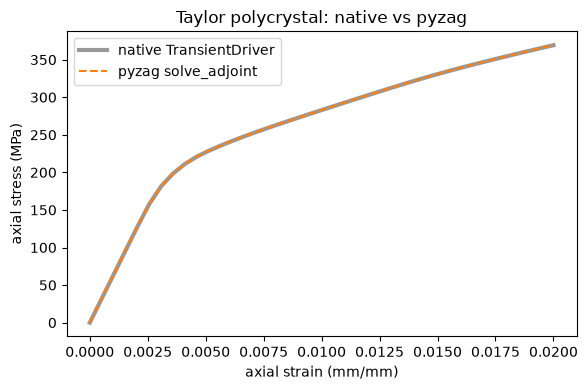

In [8]:
with torch.no_grad():
    pyzag_stress = module()

max_diff = (native_stress - pyzag_stress).abs().max().item()
rel = max_diff / pyzag_stress.abs().max().item()
print(f"max |native - pyzag| = {max_diff:.3e} MPa   (relative {rel:.2e})")
assert rel < 1e-4, "native and pyzag macroscopic responses should agree to solver tolerance"

s = strain.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    s, native_stress.detach().cpu().numpy(), "k-", lw=3, alpha=0.4, label="native TransientDriver"
)
ax.plot(s, pyzag_stress.detach().cpu().numpy(), "C1--", lw=1.5, label="pyzag solve_adjoint")
ax.set_xlabel("axial strain (mm/mm)")
ax.set_ylabel("axial stress (MPa)")
ax.set_title("Taylor polycrystal: native vs pyzag")
ax.legend()
fig.tight_layout()

## Ground truth and a perturbed start

We evaluate the model at its default hardening parameters to make a synthetic
target, then multiply those parameters by `PERTURB` to get a deliberately-wrong
starting guess.

In [9]:
truth = {n: float(getattr(model, n).detach()) for n in CALIBRATION_PARAMS}
with torch.no_grad():
    target = module()

with torch.no_grad():
    for name, factor in PERTURB.items():
        getattr(model, name).mul_(factor)
    model._update_parameter_values()
    pred_init = module()
started = {n: float(getattr(model, n).detach()) for n in CALIBRATION_PARAMS}
print("truth:  ", {k: round(v, 3) for k, v in truth.items()})
print("started:", {k: round(v, 3) for k, v in started.items()})

truth:   {'slip_strength_constant_strength': 120.0, 'voce_hardening_initial_slope': 1000.0}
started: {'slip_strength_constant_strength': 90.0, 'voce_hardening_initial_slope': 2000.0}


## Calibrate through the chunked adjoint

We rescale the parameters into `[0, 1]` space (LBFGS is sensitive to conditioning),
then run LBFGS with a strong-Wolfe line search. Each `closure` call runs the full
chunked solve and backpropagates through it via the adjoint -- so the peak memory
scales with the chunk size, not the full time history.

In [10]:
rescale_parameters(module)

optimizer = torch.optim.LBFGS(
    module.calibration_parameters, lr=1.0, max_iter=20, line_search_fn="strong_wolfe"
)
history = []


def closure():
    optimizer.zero_grad()
    loss = ((module() - target) ** 2).mean()
    loss.backward()
    return loss


for it in range(N_ITER):
    loss = float(optimizer.step(closure).detach())
    history.append(loss)
    print(f"iter {it + 1:2d}  loss = {loss:.6e}")

with torch.no_grad():
    pred_final = module()
recovered = {n: float(getattr(model, n).detach()) for n in CALIBRATION_PARAMS}
assert history[-1] < history[0]

W1007 17:50:34.319000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [23/24] torch._dynamo hit config.recompile_limit (8)
W1007 17:50:34.319000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [23/24]    function: 'matmul_3x3' (/home/tranh/projects/neml2_sep2026/pr2/neml2/types/functions.py:1838)
W1007 17:50:34.319000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [23/24]    last reason: 23/23: GLOBAL_STATE changed: grad_mode 
W1007 17:50:34.319000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [23/24] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1007 17:50:34.319000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [23/24] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


W1007 17:50:34.619000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [24/8] torch._dynamo hit config.recompile_limit (8)
W1007 17:50:34.619000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [24/8]    function: 'sym' (/home/tranh/projects/neml2_sep2026/pr2/neml2/types/functions.py:1973)
W1007 17:50:34.619000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [24/8]    last reason: 24/7: tensor 't.data' rank mismatch. expected 6, actual 7
W1007 17:50:34.619000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [24/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1007 17:50:34.619000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [24/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


W1007 17:50:34.807000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [29/8] torch._dynamo hit config.recompile_limit (8)
W1007 17:50:34.807000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [29/8]    function: 'skew' (/home/tranh/projects/neml2_sep2026/pr2/neml2/types/functions.py:1989)
W1007 17:50:34.807000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [29/8]    last reason: 29/7: GLOBAL_STATE changed: grad_mode 
W1007 17:50:34.807000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [29/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1007 17:50:34.807000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [29/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


W1007 17:50:34.936000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [27/8] torch._dynamo hit config.recompile_limit (8)
W1007 17:50:34.936000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [27/8]    function: 'r2_from_sr2' (/home/tranh/projects/neml2_sep2026/pr2/neml2/types/functions.py:1931)
W1007 17:50:34.936000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [27/8]    last reason: 27/7: tensor 's.data' size mismatch at index 1. expected 3, actual 6
W1007 17:50:34.936000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [27/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1007 17:50:34.936000 3355453 site-packages/torch/_dynamo/convert_frame.py:1853] [27/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


iter  1  loss = 6.921630e+02


iter  2  loss = 2.985874e-17


iter  3  loss = 2.985874e-17


iter  4  loss = 2.985874e-17


iter  5  loss = 2.985874e-17


## Results

The loss drops by orders of magnitude and the recovered parameters return to the
ground truth; the calibrated stress--strain curve lands back on the synthetic
target.

loss 6.922e+02 -> 2.986e-17
slip_strength_constant_strength        truth=   120.000  recovered=   120.000
voce_hardening_initial_slope           truth=  1000.000  recovered=  1000.000


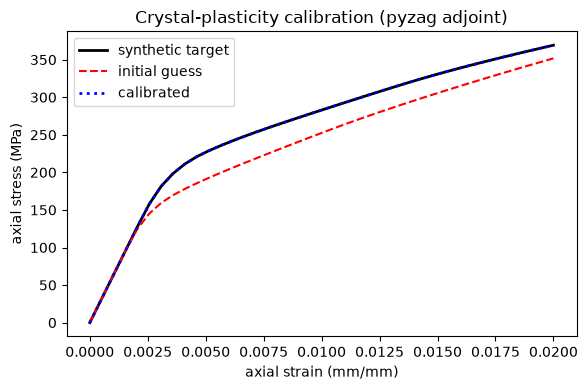

In [11]:
print(f"loss {history[0]:.3e} -> {history[-1]:.3e}")
for n in CALIBRATION_PARAMS:
    print(f"{n:38s} truth={truth[n]:10.3f}  recovered={recovered[n]:10.3f}")

s = strain.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, target.detach().cpu().numpy(), "k-", lw=2, label="synthetic target")
ax.plot(s, pred_init.detach().cpu().numpy(), "r--", label="initial guess")
ax.plot(s, pred_final.detach().cpu().numpy(), "b:", lw=2, label="calibrated")
ax.set_xlabel("axial strain (mm/mm)")
ax.set_ylabel("axial stress (MPa)")
ax.set_title("Crystal-plasticity calibration (pyzag adjoint)")
ax.legend()
fig.tight_layout()

## Where to go next

- The scalar-viscoplastic versions of this workflow are the
  [deterministic](../deterministic/main) (point estimate) and
  [statistical](../statistical/main) (Bayesian / SVI) notebooks.
- The [pyzag tutorial](tutorials-optimization-pyzag) explains *why* the chunked
  adjoint is needed for time-history calibration.
- For the underlying algorithms (chunk factorizations, predictors, block-size
  trade-offs), see the
  [pyzag documentation](https://applied-material-modeling.github.io/pyzag/).